# 💡 Phân tích dữ liệu với CSDL Thực phẩm USDA — Phần 13.4 đến 13.6

# 🥦 13.4 — Cơ sở dữ liệu thực phẩm USDA

### 🧠 Giới thiệu
#### Trong notebook này, chúng ta sẽ khám phá **Cơ sở dữ liệu Thực phẩm của Bộ Nông nghiệp Hoa Kỳ (USDA)**, chứa thông tin dinh dưỡng chi tiết cho hàng ngàn loại thực phẩm.
#### Sử dụng các thư viện Python như `pandas`, `json`, `matplotlib`, và `seaborn`, chúng ta sẽ:
- Tải và xử lý dữ liệu từ định dạng JSON.
- Gộp và làm sạch dữ liệu.
- Phân tích các nhóm thực phẩm theo giá trị dinh dưỡng.
- Trực quan hóa mối tương quan giữa các chất dinh dưỡng.

### Thư viện sử dụng

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Đọc dữ liệu JSON

In [3]:
db=json.load(open("database_usa_food.json"))
print("Tổng số loại thực phẩm : ",len(db))

Tổng số loại thực phẩm :  6636


#### 💬 Nhận xét:
 - Dữ liệu có dạng JSON gồm nhiều phần tử (mỗi phần tử là một loại thực phẩm).
 - Mỗi phần tử chứa thông tin mô tả và danh sách chi tiết các chất dinh dưỡng.

### Kiểm tra cấu trúc của phần tử đầu tiên

In [6]:
print("\nCác khóa (keys) trong bản ghi đầu tiên:", db[0].keys())


Các khóa (keys) trong bản ghi đầu tiên: dict_keys(['id', 'description', 'tags', 'manufacturer', 'group', 'portions', 'nutrients'])


#### 💬 Nhận xét:
 - Các khóa phổ biến gồm: 'id', 'description', 'group', 'manufacturer', 'portions', và 'nutrients'.
 - Trường 'nutrients' chứa danh sách các chất dinh dưỡng tương ứng với từng thực phẩm.

### Lấy bảng dinh dưỡng cho thực phẩm đầu tiên

In [7]:
nutrients = pd.DataFrame(db[0]['nutrients'])
nutrients.head()

,value,units,description,group
0,25.18,g,Protein,Composition
1,29.20,g,Total lipid (fat),Composition
2,3.06,g,"Carbohydrate, by difference",Composition
3,3.28,g,Ash,Other
4,376.00,kcal,Energy,Energy


#### 💬 Nhận xét:
 - Mỗi dòng thể hiện một chất dinh dưỡng của món ăn (ví dụ: Protein, Năng lượng, Chất béo...).
 - Bao gồm các cột như 'value' (giá trị), 'units' (đơn vị), 'description' (mô tả), và 'group' (nhóm chất).

### Trích xuất thông tin cơ bản về các loại thực phẩm

In [12]:
info_keys = ['description', 'group', 'id', 'manufacturer']
info = pd.DataFrame(db, columns=info_keys)


print("\n--- Thông tin cơ bản ---")
print(info.head())


--- Thông tin cơ bản ---
                          description                   group    id  \
0                     Cheese, caraway  Dairy and Egg Products  1008   
1                     Cheese, cheddar  Dairy and Egg Products  1009   
2                        Cheese, edam  Dairy and Egg Products  1018   
3                        Cheese, feta  Dairy and Egg Products  1019   
4  Cheese, mozzarella, part skim milk  Dairy and Egg Products  1028   

  manufacturer  
0               
1               
2               
3               
4               


#### 💬 Nhận xét:
 - Bảng info chứa tên, nhóm thực phẩm, mã định danh và nhà sản xuất (nếu có).
 - Đây là dữ liệu nền để liên kết với thông tin dinh dưỡng chi tiết sau này.

### Tạo DataFrame chứa tất cả các chất dinh dưỡng

In [14]:
nutrients_list = []
for food in db:
    fnuts = pd.DataFrame(food['nutrients'])
    fnuts['id'] = food['id']
    nutrients_list.append(fnuts)


nutrients = pd.concat(nutrients_list, ignore_index=True)


print(f"Tổng số bản ghi dinh dưỡng: {len(nutrients):,}")
nutrients.head()

Tổng số bản ghi dinh dưỡng: 389,355


,value,units,description,group,id
0,25.18,g,Protein,Composition,1008
1,29.20,g,Total lipid (fat),Composition,1008
2,3.06,g,"Carbohydrate, by difference",Composition,1008
3,3.28,g,Ash,Other,1008
4,376.00,kcal,Energy,Energy,1008


#### 💬 Nhận xét:
 - Dữ liệu hiện đã gộp toàn bộ các loại chất dinh dưỡng từ tất cả thực phẩm.
 - Mỗi hàng là một chất dinh dưỡng của một loại thực phẩm cụ thể.

### Gộp thông tin thực phẩm với bảng dinh dưỡng

In [15]:
ndata = pd.merge(nutrients, info, on='id', how='outer')

#### 💬 Nhận xét:
 - Sau khi gộp, mỗi bản ghi sẽ có đầy đủ thông tin về thực phẩm và các chất dinh dưỡng liên quan.
 - Đây là bước quan trọng để tạo ra bảng dữ liệu phân tích tổng hợp.

### Xem cấu trúc dữ liệu

In [16]:
ndata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389355 entries, 0 to 389354
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   value          389355 non-null  float64
 1   units          389355 non-null  object 
 2   description_x  389355 non-null  object 
 3   group_x        389355 non-null  object 
 4   id             389355 non-null  int64  
 5   description_y  389355 non-null  object 
 6   group_y        389355 non-null  object 
 7   manufacturer   305162 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 23.8+ MB


### 🧮 Làm sạch dữ liệu

In [17]:
ndata = ndata.drop_duplicates(subset=['description_x', 'group_x', 'id', 'value'])


ndata = ndata.rename(columns={
'description_x': 'chat_dinh_duong',
'group_x': 'nhom_chat',
'description_y': 'thuc_pham',
'group_y': 'nhom_thuc_pham'
})


ndata.head()

,value,units,chat_dinh_duong,nhom_chat,id,thuc_pham,nhom_thuc_pham,manufacturer
0,25.18,g,Protein,Composition,1008,"Cheese, caraway",Dairy and Egg Products,
1,29.20,g,Total lipid (fat),Composition,1008,"Cheese, caraway",Dairy and Egg Products,
2,3.06,g,"Carbohydrate, by difference",Composition,1008,"Cheese, caraway",Dairy and Egg Products,
3,3.28,g,Ash,Other,1008,"Cheese, caraway",Dairy and Egg Products,
4,376.00,kcal,Energy,Energy,1008,"Cheese, caraway",Dairy and Egg Products,


#### 💬 Nhận xét:
 - Đã loại bỏ bản ghi trùng lặp để đảm bảo độ chính xác khi phân tích.
 - Các cột được đổi tên rõ ràng, giúp dễ hiểu và dễ thao tác.

### Trung bình giá trị dinh dưỡng theo nhóm thực phẩm

In [18]:
mean_nutrient = ndata.groupby(['nhom_thuc_pham', 'chat_dinh_duong'])['value'].mean().unstack().fillna(0)

#### 💬 Nhận xét:
 - Tính trung bình giúp xác định nhóm thực phẩm nào có hàm lượng cao nhất cho từng loại chất dinh dưỡng.
 - Đây là bước quan trọng trong việc so sánh giá trị dinh dưỡng giữa các nhóm.

### Biểu đồ: Hàm lượng Protein trung bình theo nhóm thực phẩm

C:\Users\KHA\AppData\Local\Temp\ipykernel_20720\2025815824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


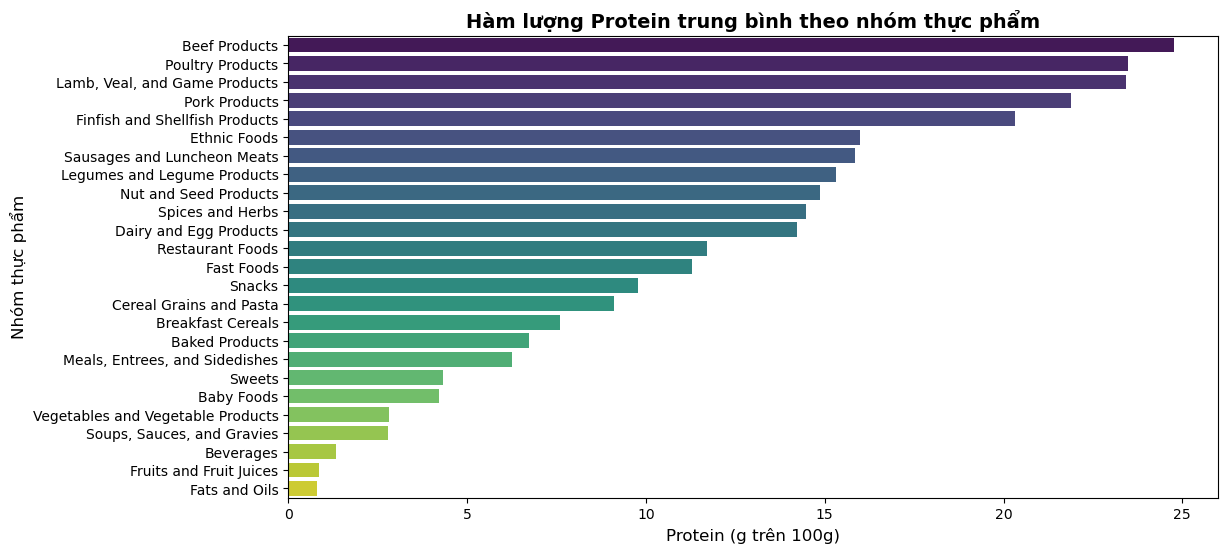

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(
y=mean_nutrient['Protein'].sort_values(ascending=False).index,
x=mean_nutrient['Protein'].sort_values(ascending=False).values,
palette='viridis'
)
plt.title('Hàm lượng Protein trung bình theo nhóm thực phẩm', fontsize=14, fontweight='bold')
plt.xlabel('Protein (g trên 100g)', fontsize=12)
plt.ylabel('Nhóm thực phẩm', fontsize=12)
plt.show()

#### 💬 Nhận xét:
 - Biểu đồ thể hiện trực quan nhóm thực phẩm nào giàu Protein nhất.
 - Dễ dàng nhận thấy các nhóm như thịt, sữa, đậu có giá trị Protein cao vượt trội.

### 🧩 Top thực phẩm giàu dinh dưỡng nhất

In [21]:
def top_foods_by_nutrient(nutrient_name, n=10):
    subset = ndata[ndata['chat_dinh_duong'] == nutrient_name]
    top_foods = subset.sort_values('value', ascending=False)[['thuc_pham', 'value', 'units', 'nhom_thuc_pham']].head(n)
    return top_foods.reset_index(drop=True)


print("\nTop 10 thực phẩm chứa nhiều Protein nhất:")
print(top_foods_by_nutrient('Protein'))


Top 10 thực phẩm chứa nhiều Protein nhất:
                                           thuc_pham  value units  \
0  Soy protein isolate, potassium type, crude pro...  88.32     g   
1  Soy protein isolate, PROTEIN TECHNOLOGIES INTE...  87.75     g   
2  Soy protein isolate, PROTEIN TECHNOLOGIES INTE...  86.00     g   
3                  Gelatins, dry powder, unsweetened  85.60     g   
4  Seal, bearded (Oogruk), meat, dried (Alaska Na...  82.60     g   
5                                Soy protein isolate  80.69     g   
6                Soy protein isolate, potassium type  80.69     g   
7   Steelhead trout, dried, flesh (Shoshone Bannock)  77.27     g   
8                                 Vital wheat gluten  75.16     g   
9         Whale, beluga, meat, dried (Alaska Native)  69.86     g   

                nhom_thuc_pham  
0  Legumes and Legume Products  
1  Legumes and Legume Products  
2  Legumes and Legume Products  
3                       Sweets  
4                 Ethnic Foods  

#### 💬 Nhận xét:
 - Kết quả giúp xác định nhanh các thực phẩm có hàm lượng Protein cao nhất.
 - Có thể ứng dụng để tư vấn dinh dưỡng hoặc xây dựng thực đơn cân đối.

### ⚗️ Phân tích mối tương quan giữa các chất dinh dưỡng

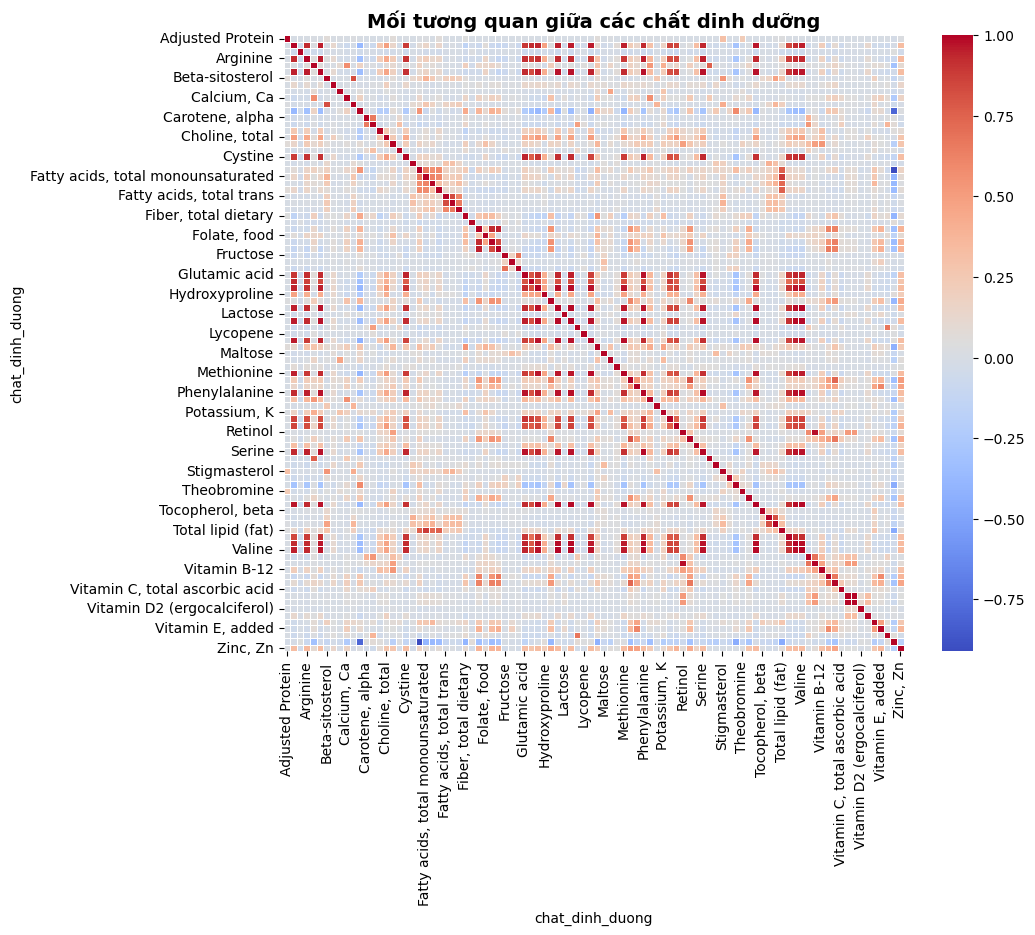

In [23]:
corr_data = ndata.pivot_table(values='value', index='thuc_pham', columns='chat_dinh_duong', aggfunc='mean').fillna(0)
corr_matrix = corr_data.corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title('Mối tương quan giữa các chất dinh dưỡng', fontsize=14, fontweight='bold')
plt.show()

#### 💬 Nhận xét:
 - Biểu đồ nhiệt cho thấy mối quan hệ giữa các chất (ví dụ: chất béo và năng lượng thường có tương quan cao).
 - Giúp hiểu rõ cách các chất dinh dưỡng ảnh hưởng lẫn nhau trong chế độ ăn.

### ✅ Kết luận
#### Trong notebook này, chúng ta đã:
 - Tải và khám phá dữ liệu **USDA Food Database** từ định dạng JSON.
 - Gộp và làm sạch dữ liệu thực phẩm và dinh dưỡng.
 - Phân tích và trực quan hóa các nhóm thực phẩm theo giá trị dinh dưỡng.
 - Minh họa mối tương quan giữa các chất dinh dưỡng khác nhau.

#### 🥗 Qua đó, ta có thể hiểu rõ hơn về thành phần dinh dưỡng trong từng nhóm thực phẩm, giúp hỗ trợ các nghiên cứu về sức khỏe, chế độ ăn uống và phân tích dữ liệu dinh dưỡng.

# 💡 Phân tích dữ liệu bầu cử Hoa Kỳ năm 2012 — Phần 13.5

## 🧠 Giới thiệu
### Dữ liệu từ **Ủy ban Bầu cử Liên bang Hoa Kỳ (Federal Election Commission - FEC)** năm 2012 chứa thông tin về các khoản đóng góp cho các ứng viên tổng thống.

### Trong phần này, chúng ta sẽ khám phá dữ liệu này, làm sạch, xử lý, và phân tích các khoản đóng góp  theo ứng viên, đảng phái và tiểu bang.

### Thư Viện Sử Dụng

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### US 13.5 — 2012 Federal Election Commission Database

- Tệp dữ liệu: P00000001-ALL.csv chứa hơn 1 triệu bản ghi đóng góp cá nhân.
- Mỗi bản ghi gồm các cột: cand_nm (tên ứng viên), contbr_nm (người đóng góp), contbr_st (bang), contbr_employer (nơi làm việc), contbr_occupation (nghề nghiệp), contb_receipt_amt (số tiền đóng góp)...

In [5]:
fec = pd.read_csv('P00000001-ALL.csv')

print(f"Tổng số bản ghi: {len(fec):,}")
print(f"Tổng số cột: {fec.shape[1]}")

Tổng số bản ghi: 536,041
Tổng số cột: 16


#### 💬 Nhận xét:
 - Đây là bộ dữ liệu lớn, bao gồm hàng triệu dòng thông tin đóng góp.
 - Cần lọc, làm sạch để dễ phân tích theo ứng viên và đảng phái.

In [6]:
fec.head()

,cmte_id,cand_id,cand_nm,contbr_nm,contbr_city,contbr_st,contbr_zip,contbr_employer,contbr_occupation,contb_receipt_amt,contb_receipt_dt,receipt_desc,memo_cd,memo_text,form_tp,file_num
0,C00410118,P20002978,"Bachmann, Michelle","HARVEY, WILLIAM",MOBILE,AL,366010290.0,RETIRED,RETIRED,250,6/20/2011,NaN,NaN,NaN,SA17A,736166
1,C00410118,P20002978,"Bachmann, Michelle","HARVEY, WILLIAM",MOBILE,AL,366010290.0,RETIRED,RETIRED,50,6/23/2011,NaN,NaN,NaN,SA17A,736166
2,C00410118,P20002978,"Bachmann, Michelle","SMITH, LANIER",LANETT,AL,368633403.0,INFORMATION REQUESTED,INFORMATION REQUESTED,250,7/5/2011,NaN,NaN,NaN,SA17A,749073
3,C00410118,P20002978,"Bachmann, Michelle","BLEVINS, DARONDA",PIGGOTT,AR,724548253.0,NONE,RETIRED,250,8/1/2011,NaN,NaN,NaN,SA17A,749073
4,C00410118,P20002978,"Bachmann, Michelle","WARDENBURG, HAROLD",HOT SPRINGS NATION,AR,719016467.0,NONE,RETIRED,300,6/20/2011,NaN,NaN,NaN,SA17A,736166


### 📊 Khám phá dữ liệu ban đầu

####  Kiểm tra các cột

In [7]:
print("\nCác cột trong bộ dữ liệu:")
print(fec.columns)


Các cột trong bộ dữ liệu:
Index(['cmte_id', 'cand_id', 'cand_nm', 'contbr_nm', 'contbr_city',
       'contbr_st', 'contbr_zip', 'contbr_employer', 'contbr_occupation',
       'contb_receipt_amt', 'contb_receipt_dt', 'receipt_desc', 'memo_cd',
       'memo_text', 'form_tp', 'file_num'],
      dtype='object')


#### Kiểm tra thông tin tổng quát

In [8]:
print("\nThông tin dữ liệu:")
fec.info()


Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536041 entries, 0 to 536040
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   cmte_id            536041 non-null  object 
 1   cand_id            536041 non-null  object 
 2   cand_nm            536041 non-null  object 
 3   contbr_nm          536041 non-null  object 
 4   contbr_city        536026 non-null  object 
 5   contbr_st          536040 non-null  object 
 6   contbr_zip         535956 non-null  float64
 7   contbr_employer    525088 non-null  object 
 8   contbr_occupation  530520 non-null  object 
 9   contb_receipt_amt  536041 non-null  int64  
 10  contb_receipt_dt   536041 non-null  object 
 11  receipt_desc       8479 non-null    object 
 12  memo_cd            49718 non-null   object 
 13  memo_text          52740 non-null   object 
 14  form_tp            536041 non-null  object 
 15  file_num           536041 non-n

##### 💬 Nhận xét:
 - Các cột quan trọng cho phân tích gồm: tên ứng viên, bang, nghề nghiệp, nơi làm việc và số tiền đóng góp.
 - Một số dữ liệu có thể bị thiếu hoặc không thống nhất (ví dụ: nghề ghi là 'INFORMATION REQUESTED').

### 🧹 Làm sạch và xử lý dữ liệu

#### Kiểm tra trùng lặp

In [13]:
fec.duplicated().sum()

16065

##### 💬Nhận Xét :
- Số lượng bản ghi trùng lặp rất lớn cần được loại bỏ 

#### Xử lí trùng lặp

In [14]:
fec=fec.drop_duplicates()

In [16]:
fec.duplicated().sum()

0

#### Loại bỏ các bản ghi có giá trị đóng góp âm (hoàn tiền)

In [17]:
fec = fec[fec['contb_receipt_amt'] > 0]

#### Kiểm tra tên ứng viên duy nhất

In [18]:
fec['cand_nm'].unique()

array(['Bachmann, Michelle', 'Romney, Mitt', 'Obama, Barack',
       "Roemer, Charles E. 'Buddy' III", 'Pawlenty, Timothy',
       'Johnson, Gary Earl', 'Paul, Ron', 'Santorum, Rick',
       'Cain, Herman', 'Gingrich, Newt', 'McCotter, Thaddeus G',
       'Huntsman, Jon', 'Perry, Rick'], dtype=object)

##### 💬 Nhận xét:
 - Có nhiều ứng viên khác nhau, bao gồm cả Barack Obama, Mitt Romney, Ron Paul, v.v.
 - Chúng ta sẽ tập trung vào các ứng viên chính đại diện cho hai đảng lớn.

#### Tạo từ điển ánh xạ giữa ứng viên và đảng phái

In [20]:
parties = {
'Obama, Barack': 'Democrat',
'Romney, Mitt': 'Republican'
}
fec['party'] = fec['cand_nm'].map(parties)

C:\Users\KHA\AppData\Local\Temp\ipykernel_18812\1823545398.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fec['party'] = fec['cand_nm'].map(parties)


In [21]:
fec.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514559 entries, 0 to 536040
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   cmte_id            514559 non-null  object 
 1   cand_id            514559 non-null  object 
 2   cand_nm            514559 non-null  object 
 3   contbr_nm          514559 non-null  object 
 4   contbr_city        514545 non-null  object 
 5   contbr_st          514558 non-null  object 
 6   contbr_zip         514491 non-null  float64
 7   contbr_employer    507481 non-null  object 
 8   contbr_occupation  512846 non-null  object 
 9   contb_receipt_amt  514559 non-null  int64  
 10  contb_receipt_dt   514559 non-null  object 
 11  receipt_desc       3052 non-null    object 
 12  memo_cd            43844 non-null   object 
 13  memo_text          46649 non-null   object 
 14  form_tp            514559 non-null  object 
 15  file_num           514559 non-null  int64  
 16  party  

#### Lọc ra chỉ hai ứng viên chính

##### 💬 Nhận xét:
 - Bây giờ dữ liệu chỉ còn hai đảng chính, giúp việc phân tích trực quan và dễ hiểu hơn.

### 🔍 Phân tích đóng góp chính trị

#### Tổng số tiền đóng góp theo đảng

In [22]:
party_totals = fec.groupby('party')['contb_receipt_amt'].sum()
print("\nTổng tiền đóng góp theo đảng:")
print(party_totals)


Tổng tiền đóng góp theo đảng:
party
Democrat      71429993
Republican    56908991
Name: contb_receipt_amt, dtype: int64


#### Biểu đồ so sánh tổng đóng góp giữa hai đảng

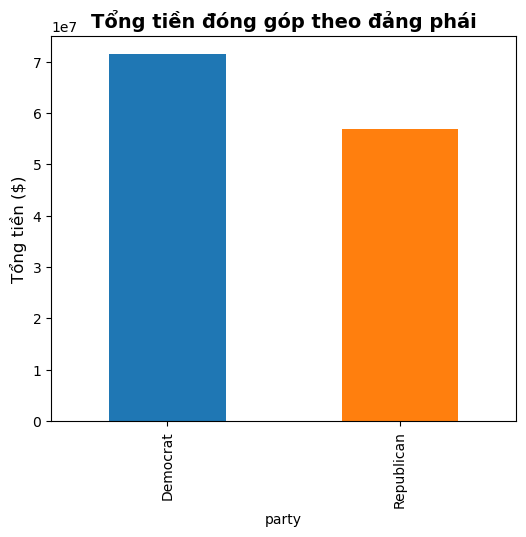

In [24]:
plt.figure(figsize=(6,5))
party_totals.plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Tổng tiền đóng góp theo đảng phái', fontsize=14, fontweight='bold')
plt.ylabel('Tổng tiền ($)', fontsize=12)
plt.show()

##### 💬 Nhận xét:
 - Biểu đồ cho thấy sự khác biệt rõ rệt giữa tổng đóng góp cho Đảng Dân chủ và Cộng hòa.
 - Barack Obama (Dân chủ) thường nhận được nhiều đóng góp nhỏ từ nhiều cá nhân hơn.

### 💼 Phân tích theo nghề nghiệp

In [25]:
occupation_totals = fec.pivot_table('contb_receipt_amt', index='contbr_occupation', columns='party', aggfunc='sum')

#### Lọc các nghề có tổng đóng góp trên 2 triệu USD

<Figure size 1000x600 with 0 Axes>

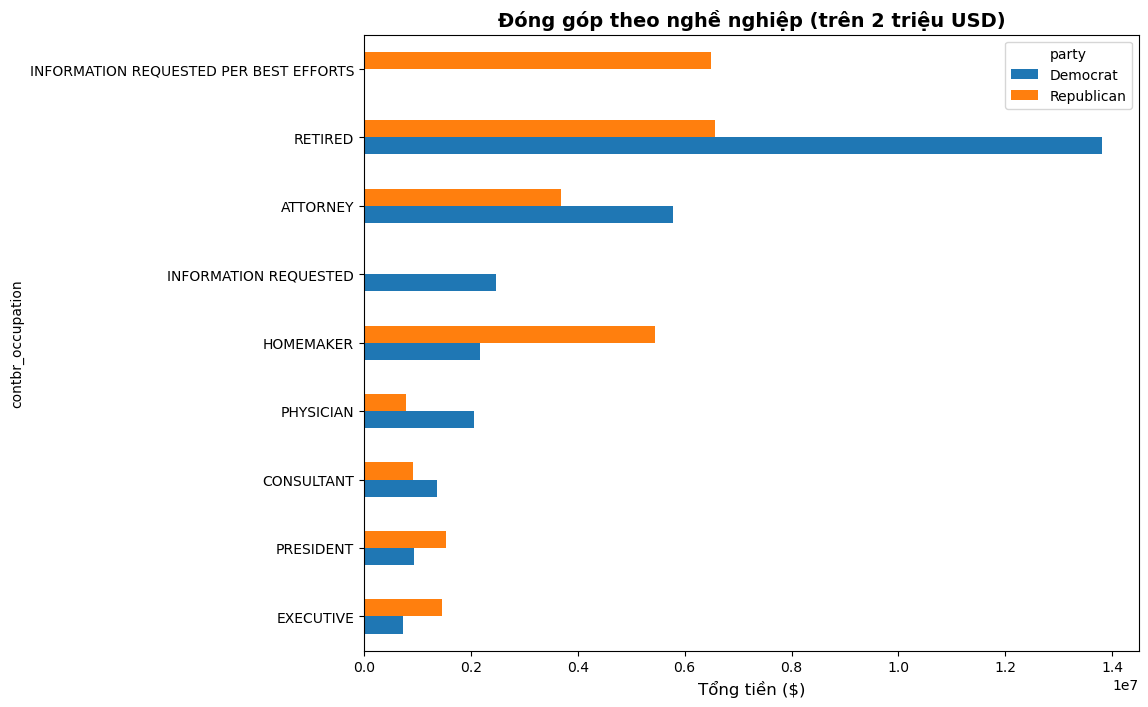

In [26]:
over_2mm = occupation_totals[occupation_totals.sum(axis=1) > 2_000_000]


plt.figure(figsize=(10,6))
over_2mm.sort_values(by='Democrat', ascending=True).plot(kind='barh', figsize=(10,8))
plt.title('Đóng góp theo nghề nghiệp (trên 2 triệu USD)', fontsize=14, fontweight='bold')
plt.xlabel('Tổng tiền ($)', fontsize=12)
plt.show()

##### 💬 Nhận xét:
 - Các nghề như luật sư, giáo viên, kỹ sư, và bác sĩ có tỷ lệ đóng góp cao.
 - Một số nghề thiên về ủng hộ Đảng Dân chủ (giáo dục, y tế), số khác thiên về Cộng hòa (doanh nghiệp, tài chính).
 - Đặc biệt ta có thể thấy sự vượt trội ở số người ủng hộ thuộc 'Retired' người đã nghỉ hưu và đang hưởng trợ cấp của nhà nước , điều này cho ta thấy phần nào chính sách của Đảng dân chủ có lợi rất lớn về An sinh xã hội và chính sách cho người lao động.

### 🌎 Phân tích theo tiểu bang

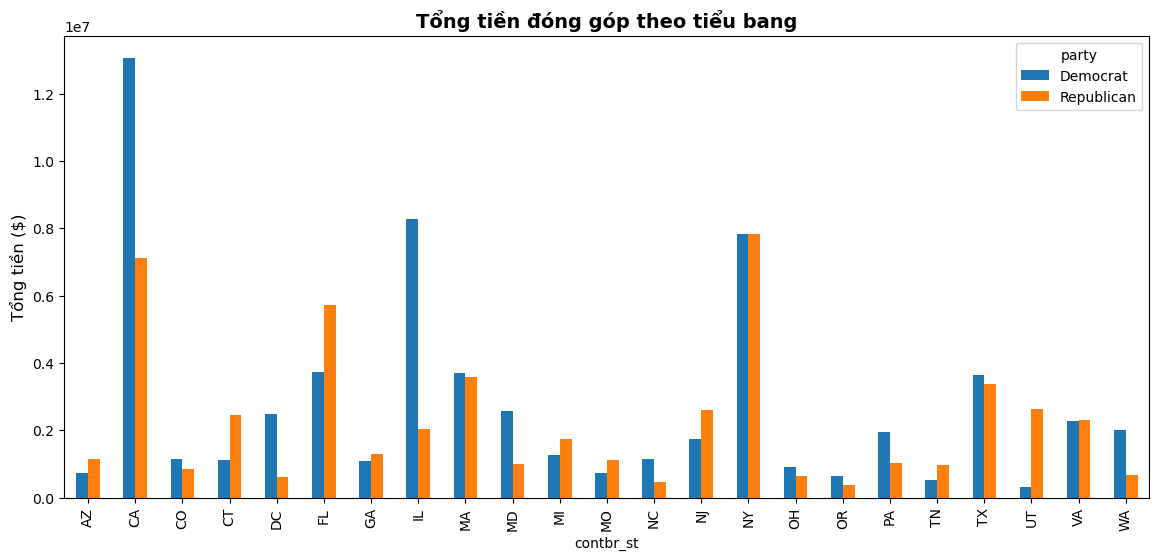

In [27]:
state_totals = fec.pivot_table('contb_receipt_amt', index='contbr_st', columns='party', aggfunc='sum')
state_totals = state_totals[state_totals.sum(axis=1) > 1_000_000]


state_totals.plot(kind='bar', figsize=(14,6))
plt.title('Tổng tiền đóng góp theo tiểu bang', fontsize=14, fontweight='bold')
plt.ylabel('Tổng tiền ($)', fontsize=12)
plt.show()

##### 💬 Nhận xét:
 - Các bang lớn như California, New York và Ilinois có tổng đóng góp cao nhất.
 - Đặc biệt với tiểu bang California đóng góp lớn nhất cho Đảng Dân Chủ với hơn 1,2 triệu đô gần gấp đôi so với đóng góp cho Đảng Cộng Hòa ở cùng tiểu bang.
 - Có thể quan sát xu hướng chính trị địa lý rõ ràng giữa hai đảng.
* Qua phân tích mức độ đóng góp qua các tiểu bang , ta nhận thấy xu hướng cử tri ủng hộ cho Đảng Dân Chủ cao hơn. Có thể đánh giá khách quan rằng chính sách của Đảng Dân Chủ lần tranh cử này rất được ủng hộ , đây có thể là yếu tố quyết định kết quả cuối cùng , đặc biệt với tiểu bang California.

### ✅ Kết luận
#### Trong phần này, chúng ta đã:
 - Tải dữ liệu đóng góp chính trị từ FEC 2012.
 - Làm sạch dữ liệu và phân loại ứng viên theo đảng.
 - Phân tích tổng đóng góp theo đảng, nghề nghiệp và tiểu bang.
 - Trực quan hóa các xu hướng đóng góp chính trị.

### 🗳️ Dữ liệu này cung cấp góc nhìn sâu sắc về hành vi đóng góp tài chính trong bầu cử Hoa Kỳ, giúp hiểu rõ hơn các yếu tố kinh tế – xã hội ảnh hưởng đến chính trị.